# BLEU

BLEU(Bilingual Evaluation Understudy)는 모델이 생성한 후보 번역과 사람이 준비한 기준 번역의 **n-gram 표현이 얼마나 겹치는지** 계산하는 자동 평가 지표이다. 같은 평가 데이터에서 번역 모델이나 생성 설정을 빠르게 비교할 때 사용한다.

BLEU는 반복 단어를 기준에 나온 횟수까지만 인정하는 **clipping**과 지나치게 짧은 후보를 낮추는 **길이 벌점(Brevity Penalty)** 을 함께 사용한다. 점수가 높아도 의미·문법·사실성이 반드시 좋은 것은 아니므로 같은 조건의 상대 비교 지표로 해석한다.


## 01. 문장 하나의 BLEU 비교

BLEU-1은 토큰 하나의 일치를 중심으로 보고, BLEU-4는 1~4개 연속 토큰의 일치를 함께 본다. 다음 예제에서는 같은 기준 번역에 세 후보만 비교한다.

- **부분 일치 후보**: 일부 단어만 다르므로 중간 정도의 점수를 얻는다.
- **짧은 후보**: 포함된 단어가 맞아도 기준보다 짧아 길이 벌점을 받는다.
- **반복 후보**: `나는`을 반복해도 기준에서 허용되는 횟수만 일치로 인정된다.

짧은 문장은 높은 차수의 n-gram을 만들지 못해 BLEU-4가 0이 되기 쉽다. `SmoothingFunction().method1`은 이 0점 문제를 완화하지만 실제로 없던 일치를 만들거나 번역 품질을 높이는 효과는 없다.


In [1]:
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu

# 한 후보 문장과 비교할 수 있도록 여러 기준 번역을 2중 리스트로 묶는다.
references = [
    "나는 학교에 갔다".split(),
    "나는 수업에 갔다".split(),
    "나는 스쿨에 갔다".split(),
]
candidates = {
    "부분 일치": "나는 도서관에 갔다".split(),
    "짧은 후보": "나는 갔다".split(),
    "반복 후보": "나는 나는 나는".split(),
}

# 짧은 문장에서 고차 n-gram이 없어 BLEU-4가 바로 0이 되는 현상을 완화한다.
smoothing = SmoothingFunction().method1

# sentence_bleu는 반복 토큰을 기준 번역에서 인정되는 최대 횟수까지만 일치로 계산한다.
for name, candidate in candidates.items():
    bleu1 = sentence_bleu(
        references,
        candidate,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoothing,
    )
    bleu4 = sentence_bleu(
        references,
        candidate,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing,
    )
    print(f"{name:8s} | BLEU-1={bleu1:.4f} | BLEU-4={bleu4:.4f}")


부분 일치    | BLEU-1=0.6667 | BLEU-4=0.1351
짧은 후보    | BLEU-1=0.6065 | BLEU-4=0.1079
반복 후보    | BLEU-1=0.3333 | BLEU-4=0.1136


## 02. 여러 문장을 평가하는 corpus BLEU

`sentence_bleu`는 후보 한 문장을 평가한다. `corpus_bleu`는 여러 문장의 일치 횟수와 길이를 모아 말뭉치 전체 점수를 계산하므로 모델 전체를 비교할 때 더 적합하다.

입력은 `문장 → 가능한 기준 번역 → 토큰` 순서로 중첩한다. 후보 목록의 첫 문장은 기준 목록의 첫 묶음과 비교되어야 하므로 두 목록의 문장 순서를 같게 유지한다.


In [2]:
from nltk.translate.bleu_score import corpus_bleu

# 문장마다 가능한 기준 번역들을 묶어 `문장 → 기준 번역 → 토큰`의 3중 구조로 만든다.
references_by_sentence = [
    ["나는 학교에 갔다".split(), "나는 수업을 들으러 갔다".split()],
    ["오늘 날씨가 좋다".split(), "오늘은 날씨가 좋다".split()],
    ["기계 번역을 평가한다".split(), "번역 모델을 평가한다".split()],
]
# 후보 문장은 references_by_sentence와 같은 문장 순서로 둔다.
predictions = [
    "나는 학교에 갔다".split(),
    "오늘 날씨가 좋다".split(),
    "번역을 평가한다".split(),
]

# 문장별 점수를 평균하지 않고 전체 n-gram 일치 횟수와 길이를 합쳐 평가한다.
score = corpus_bleu(
    references_by_sentence,
    predictions,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smoothing,
)

print("평가 문장 수:", len(predictions))
print(f"corpus BLEU-4: {score:.4f}")

#  평가 문장 수 3과, 세 문장을 합산한 점수가 출력된다
# - 문장별 점수의 단순 평균이 아니라, 전체 n-gram 일치와 길이를 합쳐서 계산한 결과

평가 문장 수: 3
corpus BLEU-4: 0.3407


## 03. BLEU를 해석할 때 주의할 점

BLEU는 기준 번역과 후보 번역의 **표면적인 n-gram 중복**을 측정한다. 의미가 같은 자연스러운 의역도 표현이 다르면 낮은 점수를 받을 수 있고, 단어가 많이 겹쳐도 문법이나 전체 의미가 틀릴 수 있다.

따라서 BLEU는 다음 조건을 동일하게 유지한 모델의 상대 비교에 사용한다.

- 같은 평가 데이터와 기준 번역
- 같은 토큰화와 문장부호 처리
- 같은 BLEU 차수와 smoothing 설정

한 문장 예제는 감점 이유를 설명하는 데 사용하고, 실제 모델 비교는 corpus BLEU와 사람 평가 또는 다른 의미 기반 지표를 함께 사용한다.

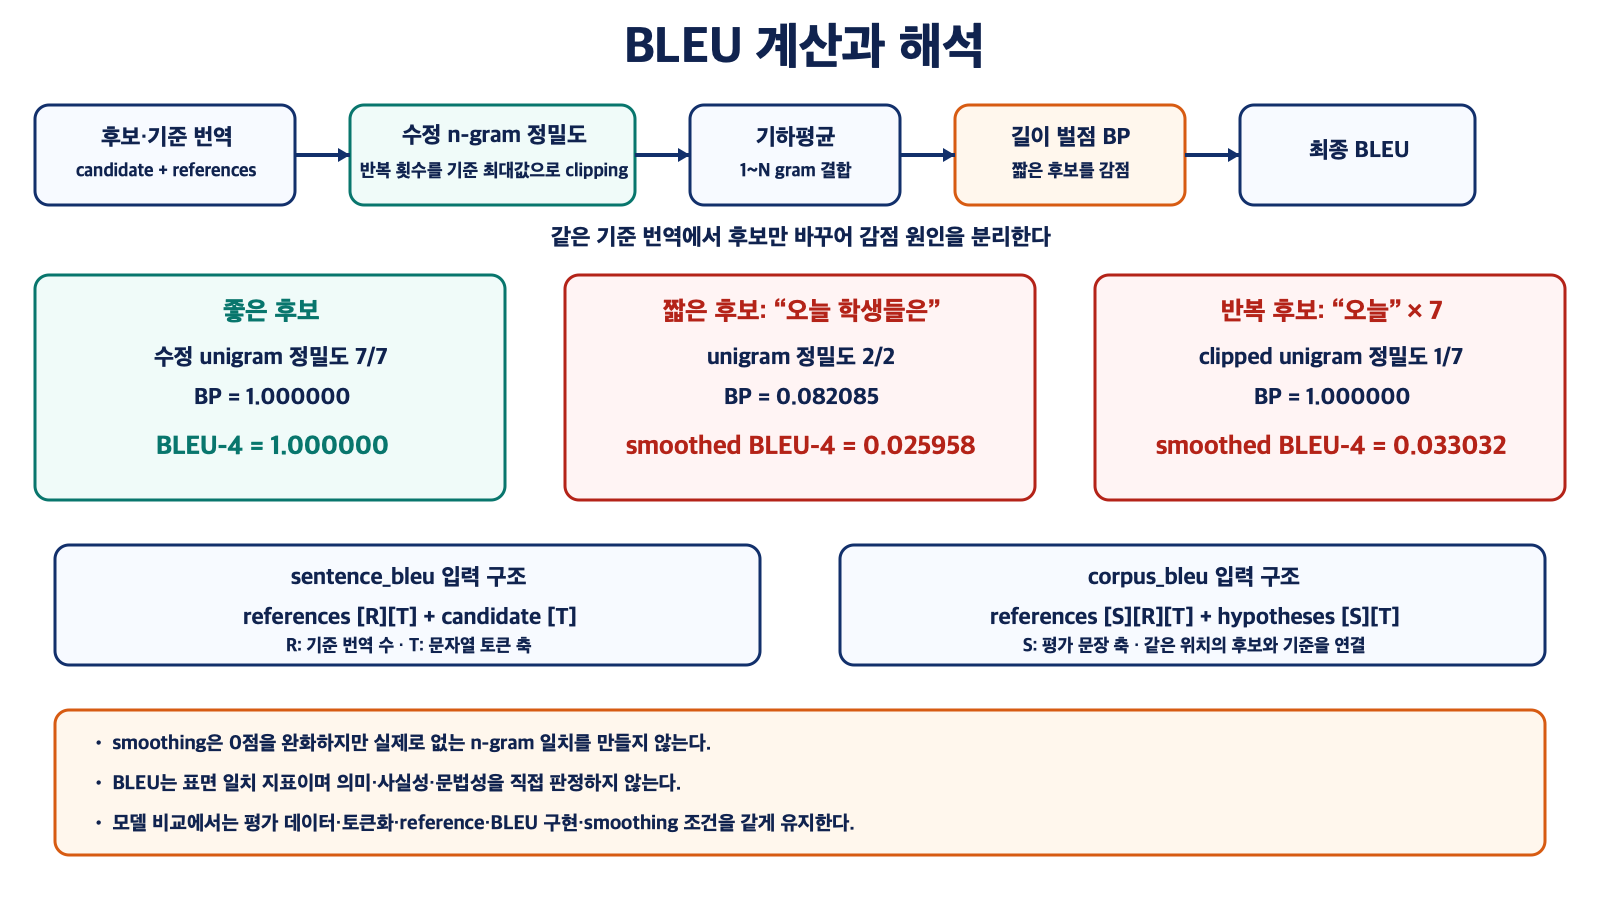
